In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

%pip install langchain_community

%pip install faiss-cpu

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/Baot/30_NLP_2025/Tair')

In [5]:
from graph_nodes_V6 import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
from graph_nodes_V6 import tools , tools_condition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import importlib
import graph_nodes_V6
importlib.reload(graph_nodes_V6)
from graph_nodes_V6 import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories # get_image_path_node
from graph_nodes_V6 import tools , tools_condition


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from langgraph.graph import StateGraph, START, END, MessagesState

from langgraph.prebuilt import ToolNode

from langchain_core.runnables import RunnableConfig, Runnable
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage, ToolCall

from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import ChatOpenAI

from trustcall import create_extractor
from typing import TypedDict, Literal, Union, Optional, List, Dict, Any

from pydantic import BaseModel, Field

from datetime import datetime

import uuid

from graph_nodes_V6 import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path
from graph_nodes_V6 import tools , tools_condition
from rag import get_rag

from IPython.display import Image, display


In [8]:
# Initialize the model
llm = ChatOpenAI(model="gpt-4o")

rag_chain = get_rag(llm)

'''
Trustcall creates and updates JSON schemas:

# Add a listener to the Trustcall extractor. This will pass runs from the extractor's execution to a class, `Spy`.
`Spy` class will extract information about what tool calls were made by Trustcall.
'''
# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.

    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []

    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )

    return "\n\n".join(result_parts)

# Creating an agent

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'eating_plan', 'instructions']

################################################################################
# Graph definition

# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    age: Optional[int] = Field(description="The user's age", default=None)
    weight: Optional[float] = Field(description="The user's weight", default=None)
    height: Optional[float] = Field(description="The user's height", default=None)
    gender: Optional[str] = Field(description="The user's gender", default=None)
    exercise_level: Optional[str] = Field(description="The user's  (amount of time spends on sport weekly)", default=None)
    diet_type: Optional[str] = Field(description="The user's diexercise level type", default=None)
    allergies: Optional[List[str]] = Field(description="The user's allergies",default_factory=list)
    medications: Optional[List[str]] = Field(description="The user's medications", default_factory=list)
    habits: Optional[List[str]] = Field(description="The user's habits", default_factory=list)
    preferences: Optional[List[str]] = Field(description="The user's preferences", default_factory=list)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    diet_goals: list[str] = Field(
        description="The user's dietary goals for which they are seeking advice, such as losing or gaining weight, improving fitness, addressing dietary restrictions like gluten intolerance.",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has",
        default_factory=list
    )

    def estimated_tdee(self) -> Optional[float]:
        if self.weight and self.height and self.age and self.gender:
            if self.gender.lower() == "male":
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age + 5
            else:
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age - 161

            activity_multiplier = {
                "low": 1.2,
                "medium": 1.55,
                "high": 1.9
            }.get((self.exercise_level or "medium").lower(), 1.55)

            return round(bmr * activity_multiplier, 2)
        return None

###############################################################################
'''
***RECOMMODATION TOOL*** - called after calories estimations and user prompt.
This function does not align with the course notebook!! make sure it is truly needed.
Justification - The recommodation part is been doing in after the estimate calories is done.
It is a tool that takes the calories estimations and based on the user profile and eating history
gives specific recommendations to the user.
Make sure the implementation is the best practice.
'''
# # Define the input schema for the tool
# class FoodAdviserInputSchema(BaseModel):
#     input_data: str  # The dish description or ingredients
#     user_profile: Optional[Dict[str, Any]] = None  # Optional user profile to override what’s in memory

# # Define the tool wrapper
# class ToolWrapper:
#     def __init__(self, func, name: str, description: str, input_schema: BaseModel):
#         self.func = func
#         self.name = name
#         self.description = description
#         self.input_schema = input_schema

#     def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
#         if isinstance(input, dict):
#             validated_input = self.input_schema(**input)
#         else:
#             validated_input = input
#         return self.func(**validated_input.model_dump(), config=config)

#     def __call__(self, input, config: Optional[RunnableConfig] = None):
#         return self.invoke(input, config)

#     def to_openai_function(self) -> Dict:
#         return {
#             "type": "function",
#             "function": {
#                 "name": self.name,
#                 "description": self.description,
#                 "parameters": self.input_schema.model_json_schema()
#             }
#         }

# # Bind the function to the tool (you already have the logic in `process_food_adviser`)
# def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
#     # You can leave this empty because `process_food_adviser` does the work,
#     # or just use this as a dummy to meet the interface.
#     return f"Processed input: {input_data} with profile: {user_profile}"

# # Instantiate the tool for registration
# food_adviser_tool = ToolWrapper(
#     func=food_adviser_function,
#     name="FoodAdviser",
#     description="Provides food recommendations and calorie estimates based on profile and dish input.",
#     input_schema=FoodAdviserInputSchema
# )

################################################################################

# EatingPlan schema
'''
TO BE CHANGE!!!!!!
Think carefully about this schema. We probably want to store information about the actual food consumed.
I also be nice to save the calorie estimation of the food consumed and grams of each ingrediant and the time of consumptoin.
maybe the agent will ask to confirm the actuall food consumed to beter manage the eating history and use it for future recommendations.
And in another section of the memory save food that was considered and not being eaten eventially.
This is good for future recommodations as well.
'''
class EatingPlan(BaseModel):
    calorie_estimations: List[str] = Field(
        description="Assistant's calorie estimations for dishes the user is considering.",
        default_factory=list
    )
    food_recommendations: List[str] = Field(
        description="Advice or suggestions regarding food choices, based on the user's profile and current dish.",
        default_factory=list
    )
    foods_consumed: List[str] = Field(
        description="Dishes or food items the user reported actually eating.",
        default_factory=list
    )
    status: Literal["considered", "consumed", "recommended"] = Field(
        description="Current status of the food item or memory update.",
        default="considered"
    )
    current_time: str = Field(
        description="Time of day when the meal was eaten (e.g., 'morning', 'lunch', 'evening').",
        default=""
    )
    timestamp: Optional[str] = Field(
        description="Optional full timestamp for logging the event.",
        default=None
    )


# Create the Trustcall extractor for updating the user profile
profile_extractor = create_extractor(
    llm,
    tools=[Profile],
    tool_choice="Profile",
)

# Chatbot instruction for choosing what to update and what tools to call
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot food adviser.

You are designed to be a companion to a user, helping them to decide what to eat depending on their preferences and text descriptions or photos of food or dishes that they upload and keep track of their menu (what they already ate).

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them)
2. The user's eating history (what they already ate), dishes they considered to eat but not actually ate and reccomendations for what they should eat.
3. General instructions for updating the eating list.

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current EatingPlan (may be empty if no dishes have been added yet):
<eating_plan>
{eating_plan}
</eating_plan>

Here are the current user-specified preferences for updating the EatingPlan (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Carefully read the user's message and the provided memories.

2. **Crucially**, decide which tool(s) are appropriate to call based *only* on the user's explicit or implicit intent in the **current turn**:
    - If the user provides **personal information**  (like name, age, weight, goals, allergies), call the \`UpdateMemory\` tool with \`update_type: 'user'\`.
    - If the user indicates they are **uploading an image** or referring to a previously uploaded image, call the \`get_image_path\` tool.
    - If the user provides a **text description of food** or asks a **question about specific food in text** (e.g., "should I eat mac and cheese", "calories in pasta"), you should signal a **text food query**. Output the specific phrase "[TEXT_FOOD_QUERY]". This phrase MUST be the very first thing in your response if you signal a text food query. Follow this phrase with a helpful response. **DO NOT** call get_calories directly.
    - If you receive results from the `get_calories` tool and they describe a specific dish, you should call the `UpdateMemory` tool with `update_type: 'eating_plan'` to log the dish as "considered" or "evaluated". Do not wait for the user to ask — always log considered food items.
    - If the user describes **something they have already eaten** and wants to log it or any food mantioned and but not eaten eventially, call the \`UpdateMemory\` tool with \`update_type: 'eating_plan'\`.
    - If the user gives **instructions or preferences** for how you should behave (e.g., "track my meals daily", "remind me about my goals"), call the \`UpdateMemory\` tool with \`update_type: 'instructions'\`.

3. Use parallel tool calls if multiple distinct tasks are requested in one message (e.g., gives personal info AND asks about food).

4. If none of the above tools are applicable, generate a helpful and relevant natural language response. Do not call any tools in this case.

5. If you signal an action (by calling a tool or specific output format), wait for the result before generating a final user response.

6. When responding after a tool call:
    - Do not explicitly state that you updated the user profile.
    - Inform the user if you have logged something to their eating plan.
    - Do not explicitly state that you updated instructions.
    - Provide a helpful response based on the results of `get_calories` or `get_image_path`.
"""

TRUSTCALL_INSTRUCTION = """Reflect on the following interaction.\n\nDetermine the appropriate memory update or food advisory tasks.

Use the provided tools to retain any necessary memories about the user.

Use parallel tool calling to handle updates and insertions simultaneously.\n\nSystem Time: {time}

"""

CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update EatingPlan list items.

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
/current_instructions>"""

# --- Define the node to extract text description ---
# This node is crucial because it performs the transformation you want:
# taking content from 'messages' and putting it into 'text_description'.
def extract_text_description(state: MessagesState) -> State:
    """
    Extracts food description from the latest human message in the state.
    It looks backwards through messages to find the most recent human input.
    """
    extracted_text = ""
    # Iterate backwards through the messages to find the latest human message
    for message in reversed(state["messages"]):
        if message.type == "human":
            extracted_text = message.content
            print(f"📝 Extracted text description from HumanMessage: {extracted_text}")
            break # Stop after finding the latest human message
        # Optional: Add logging to see other message types being skipped
        # else:
        #     print(f"⏭️ Skipping message of type: {message.type}")

    if not extracted_text:
        print("⚠️ No human message found in state to extract description.")
        # Ensure text_description is still added to the state, even if empty
        return {"text_description": ""}

    # Return a state update dictionary that adds/overwrites 'text_description'
    print(f"✅ extract_text_description returning state update: {{'text_description': '{extracted_text}'}}")

    return {"text_description": extracted_text}


# Node definitions
# --- Modify task_mAIstro to handle incoming ToolMessages ---
# task_mAIstro receives the results of tools as ToolMessages in the state['messages'] list.
# It needs to process these results and generate a final user-facing response.

def task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories, format prompt, process tool results, and get LLM response to signal intent."""

    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve profile memory from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)

    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    # Retrieve eating plan memory from the store
    namespace = ("eating_plan", user_id)
    memories = store.search(namespace)
    eating_plan = "\n".join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = ""

    # Check if the last message is a ToolMessage (result from a previous node)
    last_message = state["messages"][-1]
    if last_message.type == "tool":
        print(f"🛠️ task_mAIstro received ToolMessage result: {last_message.content}")
        # If we received a tool result, process it and generate a final response
        # You might need to use the LLM again here to synthesize the tool result
        # with the conversation history and generate a natural language response.

        # Example: Synthesize response using LLM
        synthesis_prompt = f"""
You are a helpful food adviser. You have just received the result from a tool execution.
Combine the context of the conversation and the tool result to provide a concise, user-friendly response.
Avoid mentioning "tool calls" or "tool results". If the tool reported an error, inform the user gracefully.

Conversation history:
{state['messages'][:-1]} # Exclude the current ToolMessage

Tool Result:
{last_message.content}

User Profile:
{user_profile}

Eating Plan:
{eating_plan}

Generate the final response:
"""
        final_response = llm.invoke([SystemMessage(content=synthesis_prompt)]).content
        print(f"✅ Synthesized final response: {final_response}")

        # Return the final AI message. This should not trigger further tool calls
        # and the router should route END if there are no tool calls.
        # Remove the [TEXT_FOOD_QUERY] marker if it was in the original message the LLM generated
        final_response_cleaned = final_response.replace("[TEXT_FOOD_QUERY]", "").strip()

        # If the ToolMessage was an error message, you might want to handle it differently
        if "Error:" in last_message.content or "Could not find a dish description" in last_message.content:
             return {"messages": [AIMessage(content=f"Sorry, I couldn't get the calorie estimate right now. {final_response_cleaned}")]} # Add a friendly intro for errors
        else:
             return {"messages": [AIMessage(content=final_response_cleaned)]} # Return the synthesized response

    # If the last message is NOT a ToolMessage, it's likely a new HumanMessage
    # or an AI message from a previous task_mAIstro run that didn't call a tool.
    # In this case, proceed with the initial intent analysis and potentially call a tool.

    print("🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.")

    system_msg = MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile, eating_plan=eating_plan, instructions=instructions)

    # Respond using memory as well as the chat history
    # Bind tools task_mAIstro can *call* (UpdateMemory, get_image_path).
    # We are NOT binding get_calories here for text queries.

    # Include UpdateMemory, get_calories, get_image_path (if it can call it directly)
    task_maistro_tools = [UpdateMemory, get_image_path] #  get_calories
    print(f"Binding tools to task_mAIstro: {[t.name if hasattr(t, 'name') else t.__name__ for t in task_maistro_tools]}") # Debug print

    # Invoke the model with the combined messages and bound tools
    # Invoke the model to decide the next action (tool call or signal)


    response = llm.bind_tools(task_maistro_tools).invoke([SystemMessage(content=system_msg)]+state["messages"]) # Allow parallel tool calls by default

    # The response here is the AI message containing tool calls or the [TEXT_FOOD_QUERY] signal

    return {"messages": [response]}


def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):


  """Reflect on the chat history and update the memory collection."""

  # Get the user ID from the config
  user_id = config["configurable"]["user_id"]

  # Define the namespace for the memories
  namespace = ("profile", user_id)

  # Retrieve the most recent memories for context
  existing_items = store.search(namespace)

  # Format the existing memories for the Trustcall extractor
  tool_name = "Profile"
  existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

  # Merge the chat history and the instruction
  TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
  updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

  # Invoke the extractor
  result = profile_extractor.invoke({"messages": updated_messages,
                                         "existing": existing_memories})

  # Save the memories from Trustcall to the store
  for r, rmeta in zip(result["responses"], result["response_metadata"]):
    store.put(namespace,
              rmeta.get("json_doc_id", str(uuid.uuid4())),
              r.model_dump(mode="json"),
        )

  tool_calls = state['messages'][-1].tool_calls
  return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

# --- Update Eating Plan ---
def update_eating_plan(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""

    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("eating_plan", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "EatingPlan"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()

    # Create the Trustcall extractor for updating the EatingPlan list
    eating_plan_extractor = create_extractor(
    llm,
    tools=[EatingPlan],
    tool_choice=tool_name,
    enable_inserts=True
    ).with_listeners(on_end=spy)

    # Invoke the extractor
    result = eating_plan_extractor.invoke({"messages": updated_messages,
                                    "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    # Respond to the tool call made in task_mAIstro, confirming the update
    tool_calls = state['messages'][-1].tool_calls

    # Extract the changes made by Trustcall and add the ToolMessage returned to task_mAIstro
    eating_plan_update_msg = extract_tool_info(spy.called_tools, tool_name)
    return {"messages": [{"role": "tool", "content": eating_plan_update_msg, "tool_call_id":tool_calls[0]['id']}]}


def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""

    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    namespace = ("instructions", user_id)

    existing_memory = store.get(namespace, "user_instructions")

    # Format the memory in the system prompt
    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    new_memory = llm.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store
    key = "user_instructions"
    store.put(namespace, key, {"memory": new_memory.content})
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'\n##############################################Try NOT TO USE IT ########################################################\n# # --- Process Food Adviser ---\ndef process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):\n    print("process_food_adviser: ", state)\n    message = state[\'messages\'][-1]\n    tool_calls = message.tool_calls\n\n    if not tool_calls:\n        print("❌ process_food_adviser: No tool call found.")\n        return {"messages": [AIMessage(content="❌ No tool call found for FoodAdviser.")]}\n\n    # Find the specific FoodAdviser tool call we need to respond to\n    tool_call = None\n    tool_call_id = None\n    for tc in tool_calls:\n        if tc.get(\'name\') == food_adviser_tool.name:\n            tool_call = tc\n            tool_call_id = tc[\'id\']\n            break\n\n    if not tool_call:\n         print("❌ process_food_adviser: Expected FoodAdviser tool call but didn’t find one.")\n         return {"messages": [AIMessage(

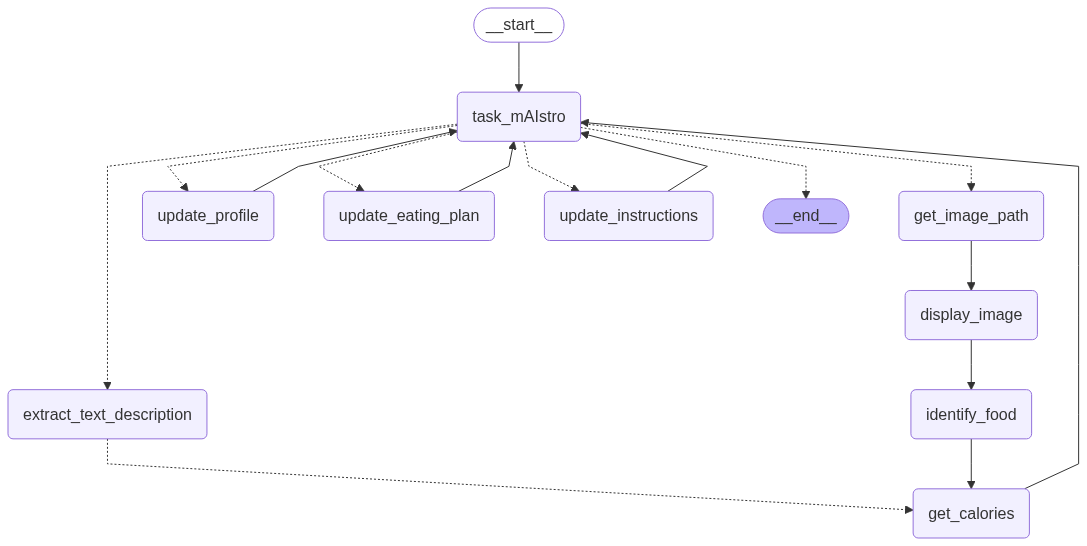

In [10]:
# Conditional edge
ReturnType = Union[type(END), Literal[
    "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description"
]]

def route_after_task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
    print("✅ route_after_task_mAIstro is running.")
    last_message = state["messages"][-1]
    print(f"🧪 last_message type: {type(last_message)}")
    print(f"🧪 last_message content: {getattr(last_message, 'content', '')}")


    # 1. Check for tool calls
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            tool_name = tool_call.get("name")
            print(f"🔧 Tool call detected from task_mAIstro: {tool_name}")

            if tool_name == "UpdateMemory":
                 update_type = tool_call.get("args", {}).get("update_type")
                 print(f"🔧 UpdateMemory tool call detected with type: {update_type}. Routing to update_{update_type}.")
                 if update_type == "user":
                     return "update_profile"
                 elif update_type == "eating_plan":
                     return "update_eating_plan"
                 elif update_type == "instructions":
                     return "update_instructions"
                 else:
                     print(f"⚠️ Unknown UpdateMemory type: {update_type}. Routing to END.")
                     return END

            # elif tool_name == get_image_path.__name__:
            elif tool_name == "get_image_path":
                 print(f"🔧 {get_image_path} tool call detected. Routing to {get_image_path}.")
                 return "get_image_path"

        print(f"⚠️ Tool calls found from task_mAIstro, but none matched a route. Checking for text food query signal.")

    # 2. Check for AI message that includes [TEXT_FOOD_QUERY]
    if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
        print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
        return "extract_text_description"

    # Check for the specific text food query signal in the AI message content
    # if hasattr(last_message, "content") and "[TEXT_FOOD_QUERY]" in last_message.content:
    #      print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
    #      return "extract_text_description"
    if isinstance(last_message, HumanMessage) and isinstance(last_message.content, str):
      print("🟡 Pure text input detected from user — assuming it's a food description.")
      return "extract_text_description"


    print("✅ No tool call or specific signal detected after task_mAIstro. Ending graph.")
    return END


# --- Graph Definition ---
workflow = StateGraph(MessagesState)

workflow.add_node("task_mAIstro", task_mAIstro)
workflow.add_node("extract_text_description", extract_text_description) # Add the new node

# Image pipeline nodes
workflow.add_node("get_image_path", ToolNode([get_image_path]))
workflow.add_node("display_image", display_image)
workflow.add_node("identify_food", identify_food)
workflow.add_node("get_calories", get_calories) # get_calories node is still needed

# Memory update nodes
workflow.add_node("update_profile", update_profile)
workflow.add_node("update_eating_plan", update_eating_plan)
workflow.add_node("update_instructions", update_instructions)

# Initial entry point
workflow.add_edge(START, "task_mAIstro")

# Conditional edge FROM task_mAIstro
workflow.add_conditional_edges(
    "task_mAIstro",
    route_after_task_mAIstro,
    {
        "update_profile": "update_profile",
        "update_eating_plan": "update_eating_plan",
        "update_instructions": "update_instructions",
        "get_image_path": "get_image_path",
        "extract_text_description": "extract_text_description", # Route text food query signal here
        END: END,
    }
)

# Edge from text extraction to get_calories
# After extracting the text description into the state, proceed to get_calories
# workflow.add_edge("extract_text_description", "get_calories")
# Define a simple router that always returns "get_calories"
def route_to_get_calories(state: MessagesState) -> Literal["get_calories"]:
    print("➡️ Routing from extract_text_description to get_calories")
    return "get_calories"

# Add a conditional edge from extract_text_description using the simple router
workflow.add_conditional_edges(
    "extract_text_description",
    route_to_get_calories,
    {"get_calories": "get_calories"}
)



# Edges FROM tool execution nodes back TO task_mAIstro
# These edges ensure the results are passed back for task_mAIstro to synthesize a response.
workflow.add_edge("get_calories", "task_mAIstro") # Route calorie result back
workflow.add_edge("update_eating_plan", "task_mAIstro")
workflow.add_edge("update_profile", "task_mAIstro")
workflow.add_edge("update_instructions", "task_mAIstro") # Assuming this is update_instructions

# Image pipeline edges
workflow.add_edge("get_image_path", "display_image")
workflow.add_edge("display_image", "identify_food")
workflow.add_edge("identify_food", "get_calories") # After identifying image food, call get_calories


# Store and compile
across_thread_memory = InMemoryStore()
within_thread_memory = MemorySaver()
graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [11]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="My name is Bar and I'm 37 years old")] # "I'm pregnant and want to control my weight. What can I eat?"

# "Is it advisable to eat pasta with tumato souse?"

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


================================ Human Message =================================

My name is Bar and I'm 37 years old
🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.
Binding tools to task_mAIstro: ['UpdateMemory', 'get_image_path']
✅ route_after_task_mAIstro is running.
🧪 last_message type: <class 'langchain_core.messages.ai.AIMessage'>
🧪 last_message content: 
🔧 Tool call detected from task_mAIstro: UpdateMemory
🔧 UpdateMemory tool call detected with type: user. Routing to update_user.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_Ih8o21NriUjt9RG9MzXiasyH)
 Call ID: call_Ih8o21NriUjt9RG9MzXiasyH
  Args:
    update_type: user
================================= Tool Message =================================

updated profile
🛠️ task_mAIstro received ToolMessage result: updated profile
✅ Synthesized final response: Thanks for sharing your details, Bar! Your age has been updated in your profile. 

In [12]:
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [
    HumanMessage(content="I'm at my favorite restaurant. I'm thinking of ordering pasta with mushrooms and heavy cream. Is it advisable?")
]

result = graph.invoke({"messages": input_messages}, config=config)

for msg in result["messages"]:
    msg.pretty_print()


🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.
Binding tools to task_mAIstro: ['UpdateMemory', 'get_image_path']
✅ route_after_task_mAIstro is running.
🧪 last_message type: <class 'langchain_core.messages.ai.AIMessage'>
🧪 last_message content: [TEXT_FOOD_QUERY]When considering pasta with mushrooms and heavy cream, it's important to think about your dietary goals and any health considerations. This dish can be high in calories and fat due to the heavy cream, so it might be rich and indulgent. If you're looking to manage calorie intake, you might want to enjoy it in moderation or consider a lighter option if available. Do you have any dietary goals or preferences that might influence your decision?
💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.
📝 Extracted text description from HumanMessage: I'm at my favorite restaurant. I'm thinking of ordering pasta with mushrooms and heavy cream. Is it advisable?
✅ extract_text_description retur

In [16]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="Here's a photo of my meal.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

Testing graph with image input:
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.
Binding tools to task_mAIstro: ['UpdateMemory', 'get_image_path']
Error: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_ta6lXIQC1EvSF4pNtVYHlWsA", 'type': 'invalid_request_error', 'param': 'messages.[13].role', 'code': None}}


Traceback (most recent call last):
  File "<ipython-input-16-4ca7e2f14983>", line 10, in <cell line: 0>
    for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
  File "/usr/local/lib/python3.11/dist-packages/langgraph/pregel/__init__.py", line 2436, in stream
    for _ in runner.tick(
  File "<ipython-input-8-0942cbc9bc99>", line 556, in task_mAIstro
    response = llm.bind_tools(task_maistro_tools).invoke([SystemMessage(content=system_msg)]+state["messages"]) # Allow parallel tool calls by default
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/langchain_core/runnables/base.py", line 5430, in invoke
    return self.bound.invoke(
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/langchain_core/language_models/chat_models.py", line 372, in invoke
    self.generate_prompt(
  File "/usr/local/lib/python3.11/dist-pack

In [ ]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="My name is Bar and I'm turning 38 next month. This is my third pregnency. I'm quite worried about my body - I want to remain fit. I'm at a resturant for lunch time. Here's a photo of what I think to eat:.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


In [17]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="I had a yugort and granola this morning. Can I load an image and you'll help me descide of to eat this dish for lunch?")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


Testing graph with image input:
Node: HumanMessage
Content: I had a yugort and granola this morning. Can I load an image and you'll help me descide of to eat this dish for lunch?
--------------------------------------------------
🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.
Binding tools to task_mAIstro: ['UpdateMemory', 'get_image_path']
Error: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_ta6lXIQC1EvSF4pNtVYHlWsA", 'type': 'invalid_request_error', 'param': 'messages.[13].role', 'code': None}}


Traceback (most recent call last):
  File "<ipython-input-17-59eaa7877c3b>", line 10, in <cell line: 0>
    for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
  File "/usr/local/lib/python3.11/dist-packages/langgraph/pregel/__init__.py", line 2436, in stream
    for _ in runner.tick(
  File "<ipython-input-8-0942cbc9bc99>", line 556, in task_mAIstro
    response = llm.bind_tools(task_maistro_tools).invoke([SystemMessage(content=system_msg)]+state["messages"]) # Allow parallel tool calls by default
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/langchain_core/runnables/base.py", line 5430, in invoke
    return self.bound.invoke(
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/langchain_core/language_models/chat_models.py", line 372, in invoke
    self.generate_prompt(
  File "/usr/local/lib/python3.11/dist-pack